In [24]:
import kagglehub
from os import getcwd
import shutil

In [25]:
path = kagglehub.dataset_download(
    "laotse/credit-risk-dataset")
shutil.copytree(path, getcwd(), dirs_exist_ok=True)

100%|██████████| 368k/368k [00:00<00:00, 960kB/s]

Extracting files...


'/content'

In [27]:
import pandas as pd

In [28]:
df = pd.read_csv("credit_risk_dataset.csv")

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [30]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [31]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [32]:
(df.isnull().mean()*100).sort_values(ascending=False)

,0
loan_int_rate,9.563856
person_emp_length,2.747000
person_income,0.000000
person_age,0.000000
person_home_ownership,0.000000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_status,0.000000
loan_percent_income,0.000000


In [33]:
df.duplicated().sum()

np.int64(165)

In [38]:
pd.crosstab(df['loan_grade'], df['loan_status'], normalize='index')

loan_status,0,1
loan_grade,,
A,0.900402,0.099598
B,0.836815,0.163185
C,0.792482,0.207518
D,0.409392,0.590608
E,0.355140,0.644860
F,0.294606,0.705394
G,0.015625,0.984375


In [ ]:
df[df.duplicated(keep=False)].sort_values(
    df.columns.tolist()).to_csv("duplicate.csv", index=False)

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

In [39]:
pd.crosstab(
    df['person_home_ownership'],
    df['loan_status'],
    normalize='index'
).round(3)

loan_status,0,1
person_home_ownership,,
MORTGAGE,0.874,0.126
OTHER,0.689,0.311
OWN,0.925,0.075
RENT,0.684,0.316


In [43]:
df['house_ownership_risk'] = df['person_home_ownership'].replace({
    'OWN': 'STABLE',
    'MORTGAGE': 'STABLE',
    'RENT': 'NON_STABLE',
    'OTHER': 'NON_STABLE'
})

In [44]:
pd.crosstab(
    df['house_ownership_risk'],
    df['loan_status'],
    normalize='index'
).round(3)

loan_status,0,1
house_ownership_risk,,
NON_STABLE,0.684,0.316
STABLE,0.882,0.118


In [42]:
import matplotlib.pyplot as plt

In [47]:
num_cols = list(df.select_dtypes("number").columns)

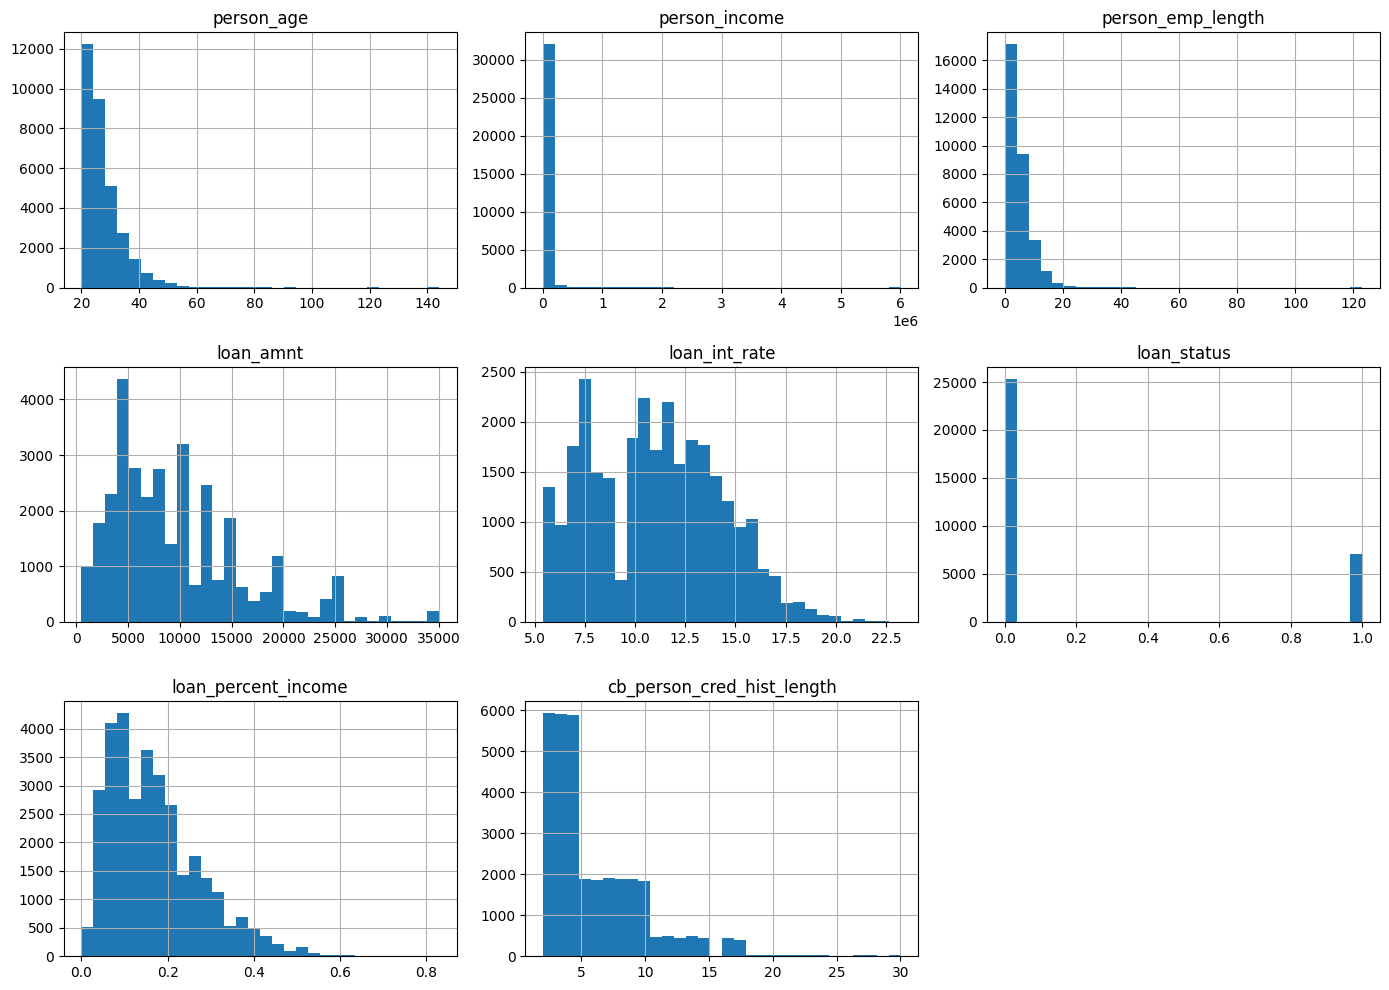

In [48]:
df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

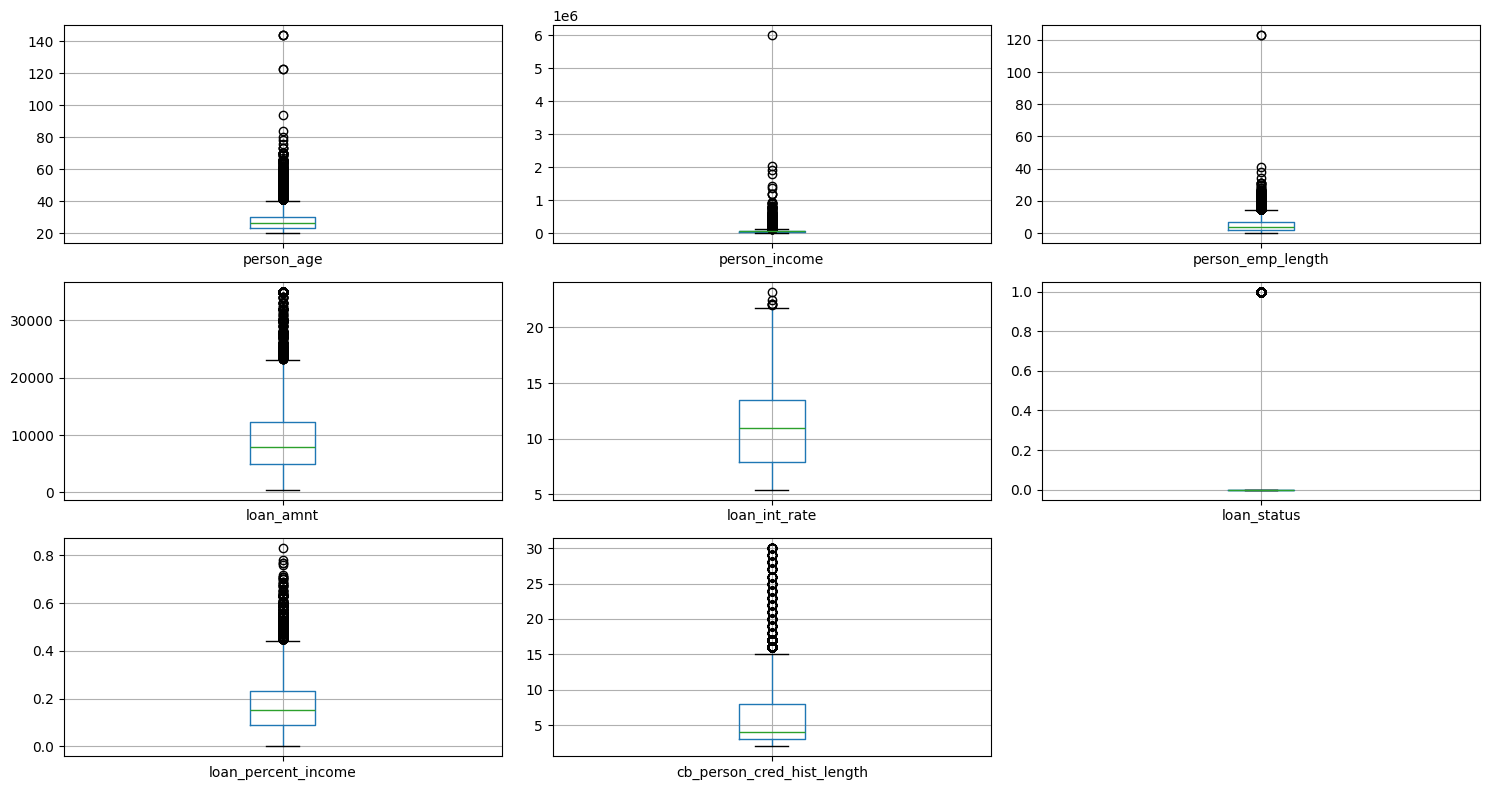

In [49]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    df.boxplot(column=col)

plt.tight_layout()
plt.show()

In [50]:
df['person_emp_length'].describe()

,person_emp_length
count,31529.00000
mean,4.79051
std,4.14549
min,0.00000
25%,2.00000
50%,4.00000
75%,7.00000
max,123.00000


In [51]:
df['person_emp_length'].value_counts().sort_index().tail(20)

,count
person_emp_length,
16.0,165
17.0,128
18.0,104
19.0,64
20.0,42
21.0,38
22.0,19
23.0,10
24.0,10


In [53]:
import numpy as np

## Replace rare outliers with NaN whose values will be put later with KNN Imputation

In [54]:
df.loc[df['person_emp_length'] == 123,
       'person_emp_length'] = np.nan

In [55]:
df.loc[df['person_age'] == 70,
       'person_age'] = np.nan

In [59]:
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].apply(lambda x: 0 if x=="N" else 1)

In [61]:
stable_df = df[df['house_ownership_risk'] == 'STABLE'].copy()

nonstable_df = df[df['house_ownership_risk'] == 'NON_STABLE'].copy()

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
x = stable_df.drop('loan_status', axis=1)
y = stable_df['loan_status']

x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)